# INF6422E – Advanced Concepts in Computer Security  
## Practical Work 3 – Winter 2026  

### Collaborative and Privacy-Aware Anomaly-Based IDS using Isolation Forest 

  
  
## Students  
- Antoine Khoueiry – *Matricule:* 2487137  
- Louis Junior Mpandzo-Otiankouya – *Matricule:* 2421549  

 

## Objective

This lab studies trustworthy and privacy-aware intrusion detection in collaborative environments 
using an anomaly-based IDS. Unlike Practical Work 1 (supervised IDS classification) and 
Practical Work 2 (security of ML under adversarial manipulation), Practical Work 3 focuses on 
deployment-oriented challenges: 
• How to detect attacks when only benign traffic is used for training (anomaly-based IDS), 
• How collaboration among multiple IDS nodes changes detection outcomes, 
• How privacy constraints (limited sharing) affect performance, 
• How to evaluate trade-offs using quantitative security metrics. 

 

## Dataset

This study uses the **CICIDS2017** dataset, combining:
- **Monday traffic** (Benign baseline)
- **Wednesday traffic** (Benign + DoS + Heartbleed)

 

## Notebook Structure

1. Centralized Anomaly-Based IDS with Isolation Forest  
2. Collaborative IDS Simulation (3 Nodes/Models) 
3. Privacy Protection in Collaborative IDS (Limited Sharing)

# 1. Centralized Anomaly-Based IDS with Isolation Forest



### 1.1 Build the Centralized Anomaly IDS 


In [8]:
import pandas as pd
import numpy as np

# load Monday data
df = pd.read_csv("MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv", low_memory=False)

# fix column name spacing
df.columns = df.columns.str.strip()

# keep only BENIGN traffic
df_benign = df[df["Label"] == "BENIGN"].copy()

print(df_benign.shape)

(529918, 79)


In [11]:
# Cleaning
df_benign.replace([np.inf, -np.inf], np.nan, inplace=True)
df_benign.dropna(inplace=True)

# Keep only features (remove the label column)
X = df_benign.drop(columns=["Label"])

# Keep numeric columns only
X = X.select_dtypes(include=[np.number])

print("Training shape:", X.shape)

Training shape: (529481, 78)


Infinite values were replaced with missing values and all incomplete rows were removed. 
Since the Isolation Forest is trained only on normal traffic, the Label column was dropped and only the numerical feature columns from the BENIGN Monday flows were kept as input to the model.

In [13]:
from sklearn.ensemble import IsolationForest

# Building the model
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
)

# Training on Monday BENIGN traffic only
iso_forest.fit(X)

print("Isolation Forest trained successfully")

Isolation Forest trained successfully


Training was performed on the Monday-WorkingHours.pcap_ISCX.csv file from the CIC-IDS-2017 MachineLearningCSV dataset.

Only the flows labeled BENIGN were retained so that the model learns a representation of normal network behaviour, as required for unsupervised anomaly detection. This way the algorithm builds a baseline of legitimate traffic patterns and any significant deviation from this baseline is later flagged as anomalous.

The model was trained using 200 trees in order to obtain more stable and less variable isolation path lengths, which improves the reliability of the anomaly score compared to a small ensemble.

The contamination rate was set to 0.01 because the training data consists only of BENIGN traffic and is therefore expected to contain at most a very small proportion of outliers due to noise or measurement artefacts. Using a low value prevents the model from forcing normal flows to be considered anomalous.

A fixed random state (42) was used so that the random feature and split selection performed during tree construction produces the same model at each run, ensuring full reproducibility of the results.

### 1.2 Map Anomaly Outputs to IDS Labels 



In [17]:
# Load Wednesday test traffic
df_test = pd.read_csv("MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv", low_memory=False)
df_test.columns = df_test.columns.str.strip()

# Clean like training  
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.dropna(inplace=True)

# Ground-truth: 0 = BENIGN, 1 = ATTACK  
y_true = (df_test["Label"].astype(str).str.strip().str.upper() != "BENIGN").astype(int)

# Features only  
X_test = df_test.drop(columns=["Label"], errors="ignore")
X_test = X_test.select_dtypes(include=[np.number])

# Align columns with training features (X from Monday) and fill missing ones with 0
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# Predict with trained Isolation Forest (iso_forest already fitted)  
# IsolationForest: 1 = normal, -1 = anomaly
y_pred_if = iso_forest.predict(X_test)

# Map to IDS labels: 0 = BENIGN, 1 = ATTACK
y_pred = (y_pred_if == -1).astype(int)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("Attack predicted count:", int(y_pred.sum()))

y_true shape: (691406,)
y_pred shape: (691406,)
Attack predicted count: 138659


Anomaly detection is appropriate when attack labels are limited or unreliable because it does not need examples of every type of attack to learn. The model is trained only on normal network traffic and learns what normal looks like, so any behaviour that is very different from this baseline is considered suspicious. In real networks, many attacks are new, unknown or incorrectly labeled, which makes supervised methods less effective since they depend on accurate attack data. By focusing only on normal traffic, anomaly detection can still identify unusual and potentially malicious activities even when the labels are incomplete or noisy.

### 1.3 Quantitative Performance Evaluation (Security Metrics) 

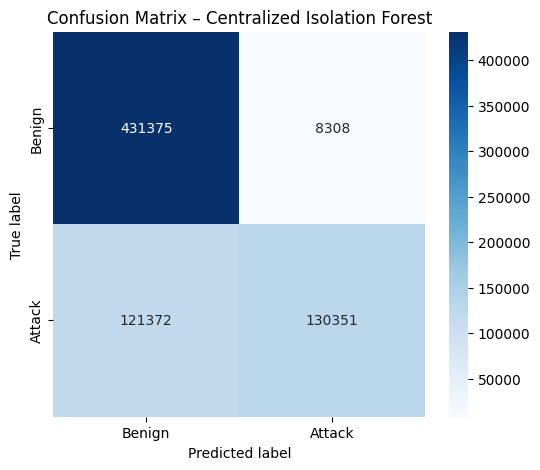

Confusion Matrix:
 [[431375   8308]
 [121372 130351]]

Precision: 0.9400832257552701
Recall   : 0.517835080624337
F1-score : 0.6678125528328662
FPR: 0.018895431481317223
FNR: 0.4821649193756629


,Metric,Value
0,Precision,0.940083
1,Recall,0.517835
2,F1-score,0.667813
3,FPR,0.018895
4,FNR,0.482165


In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Benign", "Attack"],
            yticklabels=["Benign", "Attack"])

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix – Centralized Isolation Forest")
plt.show()

# Basic metrics
precision = precision_score(y_true, y_pred)
recall    = recall_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)


print("\nPrecision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("FPR:", fpr)
print("FNR:", fnr)


results = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1-score", "FPR", "FNR"],
    "Value": [precision, recall, f1, fpr, fnr]
})

results

False Negatives are more dangerous than False Positives because they correspond to real attacks that are not detected and therefore remain inside the network, this directly compromises security. Whereas False Positives only generate additional alerts without allowing malicious activity to pass.

Yes the model clearly favours a low False Positive Rate (≈ 1.9%) at the expense of a high False Negative Rate (≈ 48%), as also reflected by the relatively low recall (≈ 0.52). This means the IDS is conservative in raising alarms. It rarely flags benign traffic as malicious, but it misses a large portion of attacks.

## 2. Collaborative IDS Simulation (3 Nodes/Models)

### 2.1 Create Three IDS Nodes (Distributed Training) 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


# Split Monday BENIGN X into 3 non-overlapping subsets
# Assumes you already have X from 1.1 (Monday BENIGN features only)
rng = np.random.RandomState(42)
idx = rng.permutation(len(X))
n = len(X)

X_A = X.iloc[idx[: n//3]]
X_B = X.iloc[idx[n//3 : 2*n//3]]
X_C = X.iloc[idx[2*n//3 :]]

print("Node sizes:", X_A.shape, X_B.shape, X_C.shape)

# Train one Isolation Forest per node
# same hyperparams you used in 1.1
def train_node(X_part):
    model = IsolationForest(
        n_estimators=200,
        contamination=0.01,
        random_state=42,
    )
    model.fit(X_part)
    return model

ids_A = train_node(X_A)
ids_B = train_node(X_B)
ids_C = train_node(X_C)

print("Trained: ids_A, ids_B, ids_C")

# Load same test set for all nodes (Wednesday = benign + attack)
test_path = "MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv"
df_test = pd.read_csv(test_path, low_memory=False)
df_test.columns = df_test.columns.str.strip()

# Clean test set
df_test.replace([np.inf, -np.inf], np.nan, inplace=True)
df_test.dropna(inplace=True)

# Ground truth AFTER cleaning: 0 = BENIGN, 1 = ATTACK
y_true = (df_test["Label"].astype(str).str.strip().str.upper() != "BENIGN").astype(int)

# Features
X_test = df_test.drop(columns=["Label"], errors="ignore")
X_test = X_test.select_dtypes(include=[np.number])

# Align feature columns with training X (important)
X_test = X_test.reindex(columns=X.columns, fill_value=0)


# Evaluate each node independently + produce per-node metrics
def eval_node(model, X_test, y_true):
    # If predict: 1=normal, -1=anomaly -> map to 0=BENIGN, 1=ATTACK
    y_pred = (model.predict(X_test) == -1).astype(int)

    cm = confusion_matrix(y_true, y_pred)  # [[TN FP],[FN TP]]
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)

    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0

    return {
        "ConfusionMatrix": cm,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "FNR": fnr
    }

res_A = eval_node(ids_A, X_test, y_true)
res_B = eval_node(ids_B, X_test, y_true)
res_C = eval_node(ids_C, X_test, y_true)

print("Node A Confusion Matrix:\n", res_A["ConfusionMatrix"])
print("Node B Confusion Matrix:\n", res_B["ConfusionMatrix"])
print("Node C Confusion Matrix:\n", res_C["ConfusionMatrix"])


# Results table (Node A/B/C separately)
results_table = pd.DataFrame([
    {"Node": "A", "Precision": res_A["Precision"], "Recall": res_A["Recall"], "F1": res_A["F1"], "FPR": res_A["FPR"], "FNR": res_A["FNR"]},
    {"Node": "B", "Precision": res_B["Precision"], "Recall": res_B["Recall"], "F1": res_B["F1s"], "FPR": res_B["FPR"], "FNR": res_B["FNR"]},
    {"Node": "C", "Precision": res_C["Precision"], "Recall": res_C["Recall"], "F1": res_C["F1"], "FPR": res_C["FPR"], "FNR": res_C["FNR"]},
])

results_table

Node sizes: (176493, 78) (176494, 78) (176494, 78)
Trained: ids_A, ids_B, ids_C
Node A Confusion Matrix:
 [[431406   8277]
 [112044 139679]]
Node B Confusion Matrix:
 [[431319   8364]
 [129210 122513]]
Node C Confusion Matrix:
 [[431487   8196]
 [160581  91142]]


,Node,Precision,Recall,F1,FPR,FNR
0,A,0.944058,0.554892,0.698956,0.018825,0.445108
1,B,0.936093,0.486698,0.640423,0.019023,0.513302
2,C,0.917494,0.362073,0.519237,0.018641,0.637927


The benign Monday dataset was randomly partitioned into three non-overlapping and approximately equal-sized subsets using a fixed random seed (42). Each subset was used to train one IDS node, to ensure that no sample appeared in more than one node.

All three IDS nodes were evaluated independently on the same Wednesday test dataset containing both benign and attack traffic.



### 2.2 Collaborative Decision Rules (Fusion Strategies) 


## 3. Privacy Protection in Collaborative IDS (Limited Sharing)

### 3.1 Feature Sharing Restriction


### 3.2  Quantifying the Privacy–Detection Trade-off 

# Conclusion

